In [61]:
import numpy as np
import matplotlib.pyplot as plt
# Project Path Setup
from setup_project_path import (
    check_and_add_project_path,
)  # Script to check and add project path
check_and_add_project_path()
from src.AAA.aaa_algorithm import aaa, cleanup
from src.AAA.AAA_kernel import AAARep
from src.kernel_params.kernel_params import KernelParams
from scipy import integrate
from src.utils.common_funcs import initialize_fine_grid, set_time_grid, cont_integral, error_time_integrated
from src.spec_dens.spec_dens import spec_dens_gapless, spec_dens_semi_circle, SpecDensGapless
from src.decomp_kernel.InterpolDecomp import InterpolDecomp
from src.decomp_kernel.decomp_kernel import DecompKernel
from src.discr_error.discr_error import DiscrError
from src.decomp_kernel.InterpolDecomp import InterpolDecomp


In [62]:
#function that returns the spectral density
"""def spec_dens(omega):
    omega = np.asarray(omega)  # Ensure omega is a NumPy array
    result = np.zeros_like(omega)  # Initialize result array with the same shape as omega
    
    mask = np.abs(omega) < 1  # Boolean mask for values where abs(omega) < 1
    result[mask] = np.sqrt(1 - omega[mask]**2)  # Apply the formula only where the condition is True
    
    return result"""

Lambda = 20
#spec_dens = lambda x: spec_dens_gapless(x, cutoff_lower=-Lambda, cutoff_upper=Lambda) #np.sqrt(1 - x**2) # semi circle spectral density that is nonzero in the interval [-1,1]
spec_dens = SpecDensGapless(Lambda = Lambda, sharpness=1)



#set parameters
params = KernelParams(spec_dens = spec_dens, n = 8000, m = 1000, N_max = 500, delta_t = 0.01, h = 0.01, beta = 10000, phi = np.pi/4)
print("largest freq: ", np.exp(params.get_param("h") * params.get_param("m")))
print("smallest freq: ", np.exp(-params.get_param("h") * params.get_param("n")))
print(params.get_param("m"))

largest freq:  148.4131591025766
smallest freq:  4.248354255291589e-18
1000


In [63]:
#compute the continuous integral (exact) of the spectral density
time_grid = set_time_grid(params.get_param("N_max"), params.get_param("delta_t"))

cont_integral_particle = cont_integral(time_grid, params.get_param("beta"), np.inf, spec_dens ,0.)
cont_integral_holes = cont_integral(time_grid, -params.get_param("beta"), np.inf, spec_dens ,0.)


cont_integral_concat = np.concatenate((cont_integral_particle, cont_integral_holes), axis=0)


1000
[4.24835426e-18 4.26964922e-18 4.29105093e-18 ... 1.46203575e+02
 1.46936423e+02 1.47672945e+02]
wmax: 148.4131591025766


/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_63400/1705505199.py:24: RuntimeWarning: overflow encountered in exp
  f = spec_dens(x) * 1 / (1 + np.exp(-params.get_param("beta") * x))
/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_63400/1705505199.py:33: RuntimeWarning: overflow encountered in exp
  vals = spec_dens(Z) * 1 / (1 + np.exp(-params.get_param("beta") * Z))


Text(0, 0.5, 'Spectral Density')

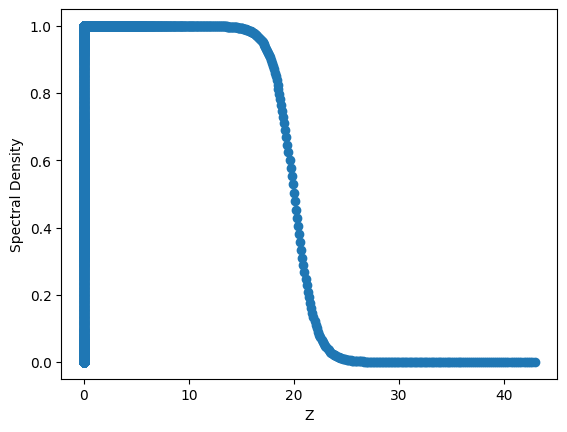

In [64]:
# explicitly get the fine frequency grid
fine_grid, _, _ = initialize_fine_grid(
    params.get_param("m"),
    params.get_param("n"),
    params.get_param("h"),
    freq_parametrization="simple_exp",
)

print(params.get_param("m"))
print(
    np.exp(
        params.get_param("h") * np.arange(-params.get_param("n"), params.get_param("m"))
    )
)
# frequency points in for negativ and positive part on real axis
Z = np.concatenate((-fine_grid[::-1], fine_grid))
#Z = fine_grid

print("wmax:", Z[-1])


# function values, determined by product of spectral density and Fermi Dirac distribution and Jacobian factor h*abs(x)
def func_exact(x):
    f = spec_dens(x) * 1 / (1 + np.exp(-params.get_param("beta") * x))
    f = np.where(np.isnan(f), 0, f)
    return f


F = func_exact(Z)

#plot the spectral density (omit the zeros in the plot)
plt.figure()
vals = spec_dens(Z) * 1 / (1 + np.exp(-params.get_param("beta") * Z))
mask = abs(vals) > 1e-10
plt.scatter(Z[mask], vals[mask])
plt.xlabel("Z")
plt.ylabel("Spectral Density")


In [65]:
"""
w_k = 10
print(Z[-1])
f = lambda x : spec_dens_gapless(x, cutoff_lower=-10, cutoff_upper=10) * np.abs(x)
F_Lorentz = f(Z)
r, errors = aaa(Z = Z, F = F_Lorentz, return_errors=True)

poles, residues = r.polres()

print(poles)
"""


'\nw_k = 10\nprint(Z[-1])\nf = lambda x : spec_dens_gapless(x, cutoff_lower=-10, cutoff_upper=10) * np.abs(x)\nF_Lorentz = f(Z)\nr, errors = aaa(Z = Z, F = F_Lorentz, return_errors=True)\n\npoles, residues = r.polres()\n\nprint(poles)\n'

In [66]:


# perform AAA algorithm on spectral density multiplied with Fermi-Dirac distribution
# r, errors = aaa(Z = Z, F = F, return_errors=True)
# r = cleanup(r, Z, F)

AAA_rep = AAARep(**params.params, tol = 1.e-10)


AAA_rep.remove_Froissart()
r_particle, errors_particle = AAA_rep.r_particle, AAA_rep.errors_particle
r_hole, errors_hole = AAA_rep.r_hole, AAA_rep.errors_hole


# Frequency grids
print(
    "\nFine grid (for positive frequencies):\n",
    "first five: ",
    fine_grid[:5],
    "\n last five: ",
    fine_grid[-5:],
)


# compute poles and residues
poles_particle, residues_particle = r_particle.polres()
poles_hole, residues_hole = r_hole.polres()




#build kernel matrices from AAA
AAA_kernel_particle, AAA_kernel_hole = AAA_rep.build_kernel(time_grid)
poles_particle_upper, residues_particle_upper, poles_hole_upper, residues_hole_upper  = AAA_rep.upper_polres()

#ID on kernels
#particles
ID_kernel_particle = InterpolDecomp(AAA_kernel_particle, full_grid = poles_particle_upper, eps = 1.e-10)
poles_ID_particle = ID_kernel_particle.coarse_grid
ID_rank_particle = ID_kernel_particle.ID_rank
idx_ID_particle = ID_kernel_particle.idx
eff_residues_particle = residues_particle_upper[idx_ID_particle[:ID_rank_particle]]
#holes
ID_kernel_hole = InterpolDecomp(AAA_kernel_hole, full_grid = poles_hole_upper, eps = 1.e-10)
poles_ID_hole = ID_kernel_hole.coarse_grid
ID_rank_hole = ID_kernel_hole.ID_rank
idx_ID_hole = ID_kernel_hole.idx
eff_residues_hole = residues_hole_upper[idx_ID_hole[:ID_rank_hole]]


weights [ 0.         -0.06911429 -0.05030604 -0.0630328  -0.04317584 -0.16232572
 -0.07355481 -0.05119842  0.00119818 -0.03713935  0.08153826  0.001985
  0.00258913  0.07731953 -0.0108854   0.05683135  0.03411299 -0.08043307
 -0.04451931 -0.00467348  0.00254404 -0.09319686  0.12696446  0.00445428
  0.00440795  0.00502889 -0.03812115 -0.0034301   0.05737373 -0.01776521
 -0.02344575 -0.00368308  0.01362537  0.06506814 -0.04623762  0.00981645
  0.00242449  0.04413092 -0.08938622 -0.09932399  0.019764   -0.01382704
 -0.00269654 -0.06127564  0.00163099 -0.02413289  0.01303434  0.0082198
 -0.00171066 -0.00407958 -0.39452274 -0.01242452 -0.08664192 -0.01089403
  0.03131083 -0.00240437 -0.00204524  0.10998993  0.09279343 -0.04413783
 -0.35140297 -0.0138346  -0.0121383  -0.08056751 -0.00148501 -0.06390287
  0.0045922   0.04223084  0.02457237 -0.07533133  0.04348499  0.02723225
  0.08748871  0.06111905 -0.00870051  0.02600507  0.03931315  0.04323478
 -0.06327995  0.11968376 -0.07530334  0.005252

In [ ]:


#compute poles and residues for given spectral density
additional_poles, additional_residues = spec_dens.poles_residues()
explicit_poles, explicit_residues = spec_dens.explicit_poles_and_residues(h = params.get_param("h"), phi_low=0, phi_up=3*np.pi/8)

#decompose the kernel using ID. Specify include_additional_poles = True to include the additional poles in the kernel that is decomposed
discr_kernel = DiscrError(**params.params,  explicit_poles = explicit_poles, explicit_residues = explicit_residues, additional_poles=additional_poles, additional_residues = additional_residues)
discr_kernel.optimize(rel_error_diff=1.e-2)
print("max freq after optimization: ", discr_kernel.fine_grid[-1], "max freq before optimization: ", fine_grid[-1])
print("min freq after optimization: ", discr_kernel.fine_grid[0], "min freq before optimization: ", fine_grid[0])
print("complex grid: ", discr_kernel.fine_grid_complex[0], discr_kernel.fine_grid_complex[len(discr_kernel.fine_grid_complex)//2], discr_kernel.fine_grid_complex[-1])
decomp = DecompKernel(discr_kernel, include_additional_poles = True)
ID_rank_pure = decomp.ID_rank
idx_ID_pure = decomp.idx
coarse_grid_ID_pure = decomp.coarse_grid


print("number of AAA poles: ", len(poles_particle) + len(poles_hole))
print("ID_rank pure", ID_rank_pure)
print("Nbr. of additional poles: ", len(additional_poles))



CROASE GRID:  [-2.00000000e+01+3.14159265e+00j  2.00000000e+01+3.14159265e+00j
  2.00000000e+01+9.42477796e+00j -2.00000000e+01+9.42477796e+00j
  2.00000000e+01+1.57079633e+01j -2.00000000e+01+1.57079633e+01j
  3.07537366e+00+3.07537366e+00j -3.07537366e+00+3.07537366e+00j
 -7.89327793e-01+7.89327793e-01j  7.89327793e-01+7.89327793e-01j
 -6.81023352e+00+6.81023352e+00j  6.81023352e+00+6.81023352e+00j
 -2.46209227e-01+2.46209227e-01j  2.46209227e-01+2.46209227e-01j
  1.65438015e+00+1.65438015e+00j -1.65438015e+00+1.65438015e+00j
 -1.08963341e+01+1.08963341e+01j  1.08963341e+01+1.08963341e+01j
 -4.51961318e+00+4.51961318e+00j  4.51961318e+00+4.51961318e+00j
  8.92268219e-02+8.92268219e-02j -8.92268219e-02+8.92268219e-02j
 -2.07682714e+01+2.07682714e+01j  2.07682714e+01+2.07682714e+01j
  1.18937316e+00+1.18937316e+00j -1.18937316e+00+1.18937316e+00j
  1.42738103e+01+1.42738103e+01j -1.42738103e+01+1.42738103e+01j
 -2.34767719e+00+2.34767719e+00j  2.34767719e+00+2.34767719e+00j
 -8.4437490

Text(0.0001, 0.01, 'nbr. Froisset doublets: 24\n[i.e. abs(residue_k) < 1e-13)]')

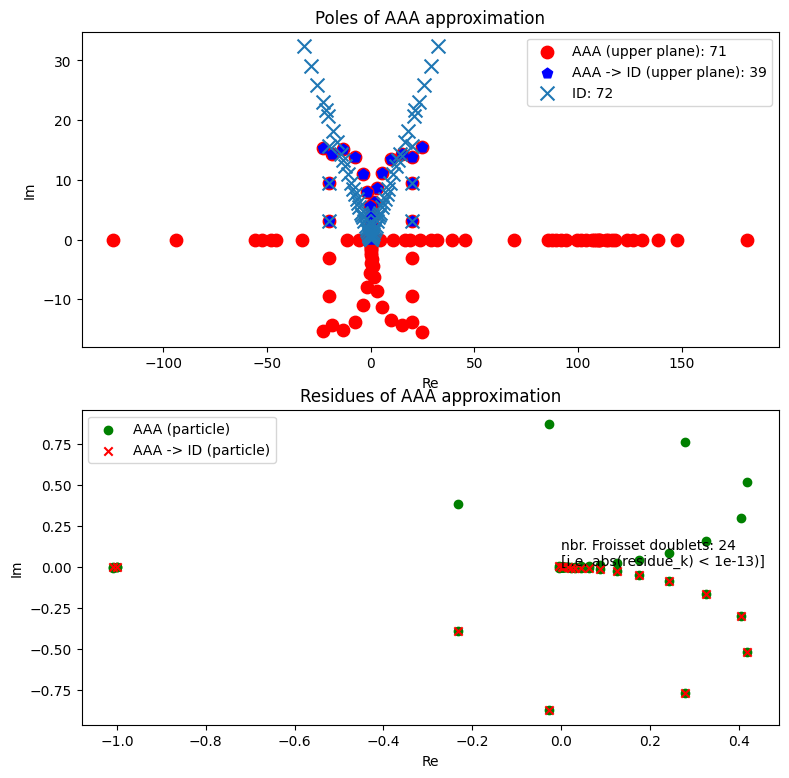

In [67]:
#plot the poles in the complex plane
#subplots in one figure
fig, axs = plt.subplots(2, 1, figsize=(9, 9))
#plot the poles in the complex plane
poles_mask_particle = np.abs(residues_particle) > 1.e-13
poles_mask_hole = np.abs(residues_hole) > 1.e-13
poles_ID_mask_particle = np.abs(eff_residues_particle) > 1.e-13
poles_ID_mask_hole = np.abs(eff_residues_hole) > 1.e-13
axs[0].scatter(poles_particle.real[poles_mask_particle], poles_particle.imag[poles_mask_particle], s = 80, color = 'red')
axs[0].scatter(poles_ID_particle.real[poles_ID_mask_particle], poles_ID_particle.imag[poles_ID_mask_particle], marker = 'p', s = 60, color = "blue")
axs[0].scatter(poles_hole.real[poles_mask_hole], poles_hole.imag[poles_mask_hole], label = f'AAA (upper plane): {len(poles_particle[poles_particle.imag > 0]) + len(poles_hole[poles_hole.imag > 0])}',   s = 80, color = 'red')
axs[0].scatter(poles_ID_hole.real[poles_ID_mask_hole], poles_ID_hole.imag[poles_ID_mask_hole], label = f'AAA -> ID (upper plane): {len(poles_ID_particle[poles_ID_particle.imag > 0]) + len(poles_ID_hole[poles_ID_hole.imag > 0])}',  marker = 'p', s = 60, color = "blue")
axs[0].scatter(coarse_grid_ID_pure.real, coarse_grid_ID_pure.imag,  label = f'ID: {ID_rank_pure}',  marker = 'x', s = 100)
print("CROASE GRID: ", coarse_grid_ID_pure)
axs[0].set_title('Poles of AAA approximation')
axs[0].legend()
axs[0].set_xlabel('Re')
axs[0].set_ylabel('Im')



#plot the residues in the complex plane
axs[1].scatter(residues_particle.real, residues_particle.imag, label = 'AAA (particle)', color = "green")
axs[1].scatter(eff_residues_particle.real, eff_residues_particle.imag, label = 'AAA -> ID (particle)', color = 'red', marker = 'x')
axs[1].set_title('Residues of AAA approximation')
axs[1].legend()
axs[1].set_xlabel('Re')
axs[1].set_ylabel('Im')
#compute number of Froisset doubles:
nbr_doublets = np.sum(np.abs(abs(residues_particle)) < 1e-10)
axs[1].text(.0001,.01, 'nbr. Froisset doublets: ' + str(nbr_doublets) + '\n' + '[i.e. abs(residue_k) < 1e-13)]')



/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_63400/1705505199.py:24: RuntimeWarning: overflow encountered in exp
  f = spec_dens(x) * 1 / (1 + np.exp(-params.get_param("beta") * x))
/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_63400/1630054595.py:4: RuntimeWarning: invalid value encountered in scalar divide
  r_check = lambda x: np.sum([res / (x - pole) for res, pole in zip(residues_particle, poles_particle)])


Text(0, 0.5, 'Absolute error: $|f_{exact}(\\omega) - f_{residues}(\\omega)|$')

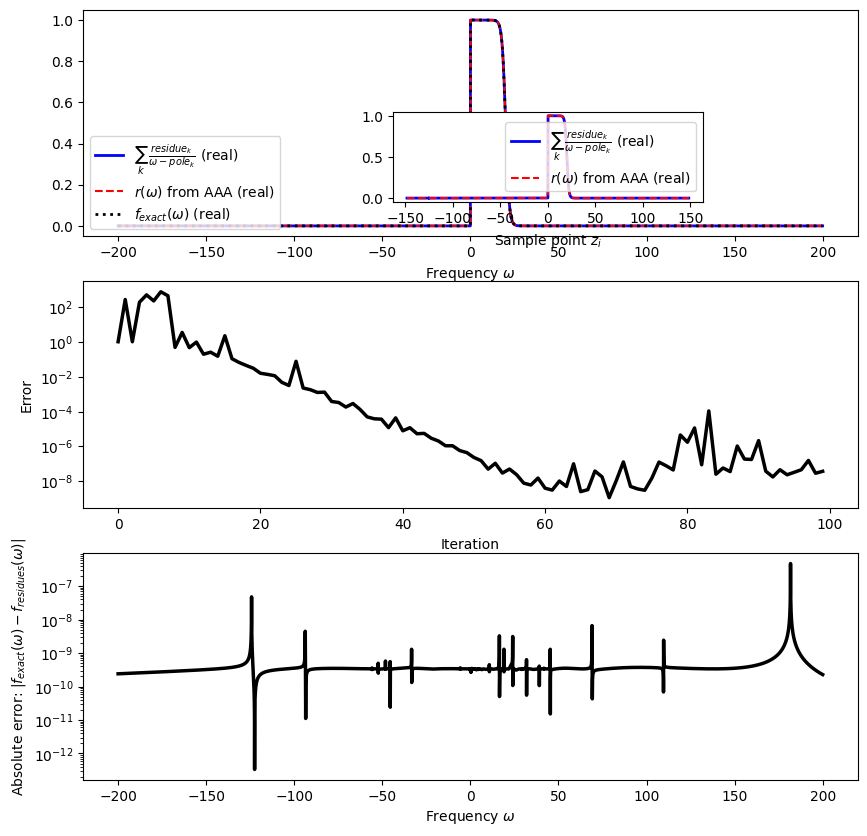

In [68]:
#check that sum over residues divided by poles gives r(z)

#define function as r_check(x) = sum_k residue_k / (x - pole_k)
r_check = lambda x: np.sum([res / (x - pole) for res, pole in zip(residues_particle, poles_particle)])

#range in which we want to plot the function
x_range = np.linspace(-200,200,10000)

#evaluate r_check(x) for each x in x_range
vals_residues = np.array([r_check(x) for x in x_range])
#evaluate func_exact(x) for each x in x_range
vals_exact = np.array([func_exact(x) for x in x_range])
#evaluate r(x) for each x in x_range
vals_rational = r_particle(x_range)


#plot the real and imaginary part of r(x) and the real and imaginary part of r_check(x)
#figure with two subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

axs[0].plot(x_range, vals_residues.real, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (real)' , linewidth = 2, color = "blue")
#axs[0].plot(x_range, vals_residues.imag, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (imag)' , linewidth = 2, color = "green")
axs[0].plot(x_range, vals_rational.real, label = r'$r(\omega)$' + ' from AAA (real)' , linestyle = '--', color = "red")
#axs[0].plot(x_range, vals_rational.imag, label = r'$r(\omega)$' + ' from AAA (imag)' , linestyle = '--')
axs[0].plot(x_range, vals_exact.real, label = r'$f_{exact}(\omega)$' + ' (real)' , linestyle = 'dotted', linewidth = 2, color = "black")
#axs[0].plot(x_range, vals_exact.imag, label = r'$f_{exact}(\omega)$' + ' (imag)' , linestyle = 'dotted', linewidth = 2, color = "brown")
axs[0].legend(loc = "lower left")
axs[0].set_xlabel('Frequency ' + r'$\omega$')

#make inset plot
axins = axs[0].inset_axes([0.4, 0.15, 0.4, 0.4])
axins.plot(Z, np.array([r_check(z) for z in Z]).real, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (real)' , linewidth = 2, color = "blue")
axins.plot(Z, r_particle(Z).real, label = r'$r(\omega)$' + ' from AAA (real)' , linestyle = '--', color = "red")
axins.legend()
axins.set_xlabel('Sample point ' + r'$z_i$')


#plot the error as function of iteration
axs[1].plot(errors_particle, label = 'Error', linewidth = 2.5, color = 'black')
axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Error')



#plot the absolute error between the exact function and the rational approximation
axs[2].plot(x_range, np.abs(vals_exact - vals_residues), label = 'Absolute error', linewidth = 2.5, color = 'black')
axs[2].set_yscale('log')
axs[2].set_xlabel('Frequency ' + r'$\omega$')
axs[2].set_ylabel('Absolute error: ' + r'$|f_{exact}(\omega) - f_{residues}(\omega)|$')


In [69]:
G_learned = AAA_rep.propagator_AAA(time_grid)
error_plain = abs(G_learned - cont_integral_concat)
#compute the error between the continuous integral and the AAA approximation
error = error_time_integrated(cont_integral_concat, G_learned, params.params["delta_t"])
print("error", error)

error 4.1500534738216776e-10


In [70]:
G_AAA_ID = ID_kernel_particle.reconstruct_propagator_ID()
error_AAA_ID = abs(G_AAA_ID - cont_integral_concat[:len(time_grid)])

G_ID_pure = decomp.reconstruct_propagator_ID()
error_ID_pure = abs(G_ID_pure - cont_integral_concat)




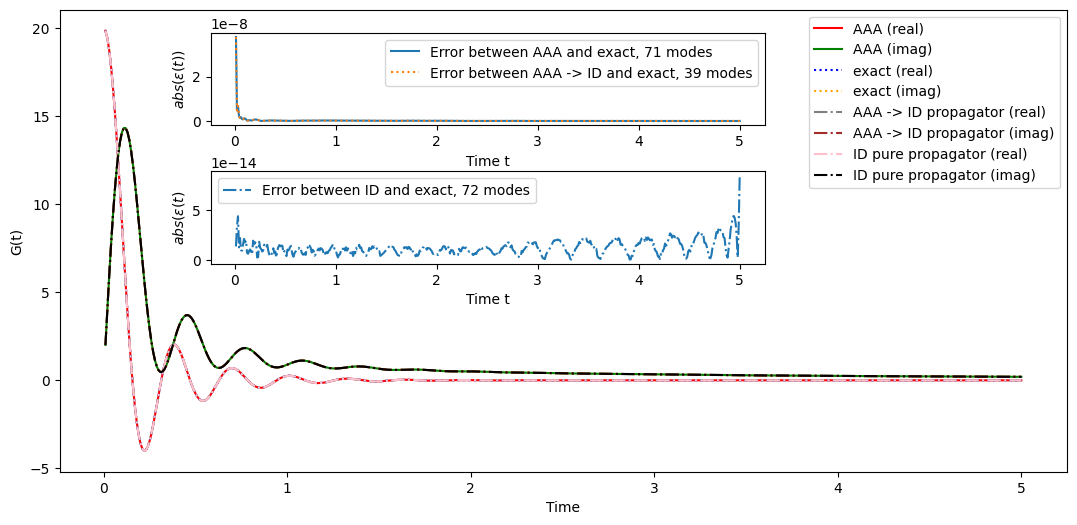

In [71]:
#compute the Green's function as contiuous integral

#check that "learned propagator is close to the reference propagator"
residues_upper = residues_particle[poles_particle.imag > 0]
poles_upper = poles_particle[poles_particle.imag > 0]



#plot the learned propagator and the reference propagator
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(time_grid, G_learned[:len(time_grid)].real, label="AAA" + ' (real)', color = 'red', linestyle = '-')
ax.plot(time_grid, G_learned[:len(time_grid)].imag, label="AAA"  ' (imag)', color = 'green', linestyle = '-')
ax.plot(time_grid, cont_integral_particle.real, label="exact" + ' (real)', color = 'blue', linestyle = 'dotted')
ax.plot(time_grid, cont_integral_particle.imag, label="exact" + ' (imag)', color = 'orange', linestyle = 'dotted')
ax.plot(time_grid, G_AAA_ID.real, label='AAA -> ID propagator' + ' (real)', color = 'gray', linestyle = 'dashdot')
ax.plot(time_grid, G_AAA_ID.imag, label='AAA -> ID propagator' + ' (imag)', color = 'brown', linestyle = 'dashdot')
ax.plot(time_grid, G_ID_pure[:len(time_grid)].real, label='ID pure propagator' + ' (real)', color = 'pink', linestyle = 'dashdot')
ax.plot(time_grid, G_ID_pure[:len(time_grid)].imag, label='ID pure propagator' + ' (imag)', color = 'black', linestyle = 'dashdot')
ax.legend()
ax.set_xlabel('Time')
ax.set_ylabel('G(t)')



axins = ax.inset_axes([0.15, 0.75, 0.55, 0.2])
axins.plot(time_grid[:], error_plain[:len(time_grid)], linestyle = '-', label = f'Error between AAA and exact, {len(poles_hole[poles_hole.imag > 0])+len(poles_particle[poles_particle.imag > 0])} modes')
axins.plot(time_grid[:], error_AAA_ID[:len(time_grid)], linestyle = 'dotted', label = f'Error between AAA -> ID and exact, {len(poles_ID_hole[poles_ID_hole.imag > 0]) +len(poles_ID_particle[poles_ID_particle.imag > 0])} modes')
axins.set_xlabel('Time t')
axins.set_ylabel(r'$abs(\epsilon(t))$')
axins.legend()


axins = ax.inset_axes([0.15, 0.45, 0.55, 0.2])
axins.plot(time_grid[:], error_ID_pure[:len(time_grid)], linestyle = 'dashdot', label = f'Error between ID and exact, {ID_rank_pure} modes')
axins.set_xlabel('Time t')
axins.set_ylabel(r'$abs(\epsilon(t)$')
axins.legend()



plt.show()
